# Análise - Ultrapassagem por corrida


##  1. Introdução

A Fórmula 1 é conhecida não apenas por sua velocidade, mas também pela complexidade estratégica das corridas. Um dos elementos mais emocionantes das provas são as ultrapassagens, ou seja, mudanças de posição durante a corrida que indicam disputas intensas entre os pilotos. 

Nesta análise, utilizamos dados oficiais de tempos de volta para estimar o número de ultrapassagens ocorridas em cada corrida entre os pilotos que terminaram a prova.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Estimar o número de ultrapassagens por corrida com base na variação de posição volta a volta;

    - Identificar quais corridas tiveram o maior número de ultrapassagens entre os pilotos que completaram a prova;

    - Observar possíveis padrões de corridas com alta movimentação de posições.


## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - lap_times.csv: contém os tempos de volta de cada piloto por corrida;
    - results.csv: traz o resultado final de cada piloto, incluindo o status (completou ou não a corrida);
    - races.csv: opcional, para adicionar contexto com ano, circuito, etc.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [9]:
import pandas as pd

# Carregando os dados
lap_times = pd.read_csv("lap_times.csv")
results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")  # <- NOVO

# Filtrando apenas pilotos que completaram a prova
finished_drivers = results[results["statusId"] == 1][["raceId", "driverId"]]

# Unindo dados de volta com dados de finalização
laps = lap_times.merge(finished_drivers, on=["raceId", "driverId"])

# Ordenando voltas por tempo e definindo posição por volta
laps = laps.sort_values(by=["raceId", "lap", "milliseconds"])
laps["position"] = laps.groupby(["raceId", "lap"])["milliseconds"].rank(method="min")

# Calculando mudança de posição em relação à volta anterior
laps["prev_position"] = laps.groupby(["raceId", "driverId"])["position"].shift(1)
laps["position_change"] = laps["prev_position"] - laps["position"]
laps["changed"] = laps["position_change"].fillna(0) != 0

# Contando total de mudanças por corrida
ultrapassagens = laps.groupby("raceId")["changed"].sum().reset_index(name="ultrapassagens")

# Adicionando nome e ano da corrida
ultrapassagens = ultrapassagens.merge(races[["raceId", "name", "year"]], on="raceId", how="left")
ultrapassagens["corrida"] = ultrapassagens["year"].astype(str) + " - " + ultrapassagens["name"]

# Ordenar para exibir top 10
top10 = ultrapassagens.sort_values(by="ultrapassagens", ascending=False).head(10)

# Exportar CSV com nome legível
ultrapassagens.to_csv("ultrapassagens_por_corrida.csv", index=False)

# Visualização rápida
print(top10[["corrida", "ultrapassagens"]])


                         corrida  ultrapassagens
452     2020 - Sakhir Grand Prix            1213
302     2013 - Monaco Grand Prix            1012
510      2023 - Dutch Grand Prix            1004
373  2016 - Brazilian Grand Prix             971
490      2022 - Dutch Grand Prix             926
525      2024 - Miami Grand Prix             914
484   2022 - Canadian Grand Prix             892
496  2022 - São Paulo Grand Prix             890
340     2015 - Monaco Grand Prix             872
430  2019 - Singapore Grand Prix             865


## 4. Conclusão
A análise revelou padrões importantes sobre a competitividade entre as escuderias na Fórmula 1:

    - Algumas equipes mantêm um desempenho dominante por décadas;

    - Outras apresentam picos de performance em períodos específicos;

    - A divisão por década permite identificar mudanças de hegemonia no esporte.

Além disso, exploramos as corridas com maior número de ultrapassagens, destacando os eventos mais movimentados da história recente. O gráfico abaixo mostra as 10 corridas com mais ultrapassagens registradas:

/var/folders/5z/p9vk7tg12wq_vpmfx1kgwpg40000gn/T/ipykernel_3107/544387864.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="corrida", y="ultrapassagens", data=top10, palette="rocket")


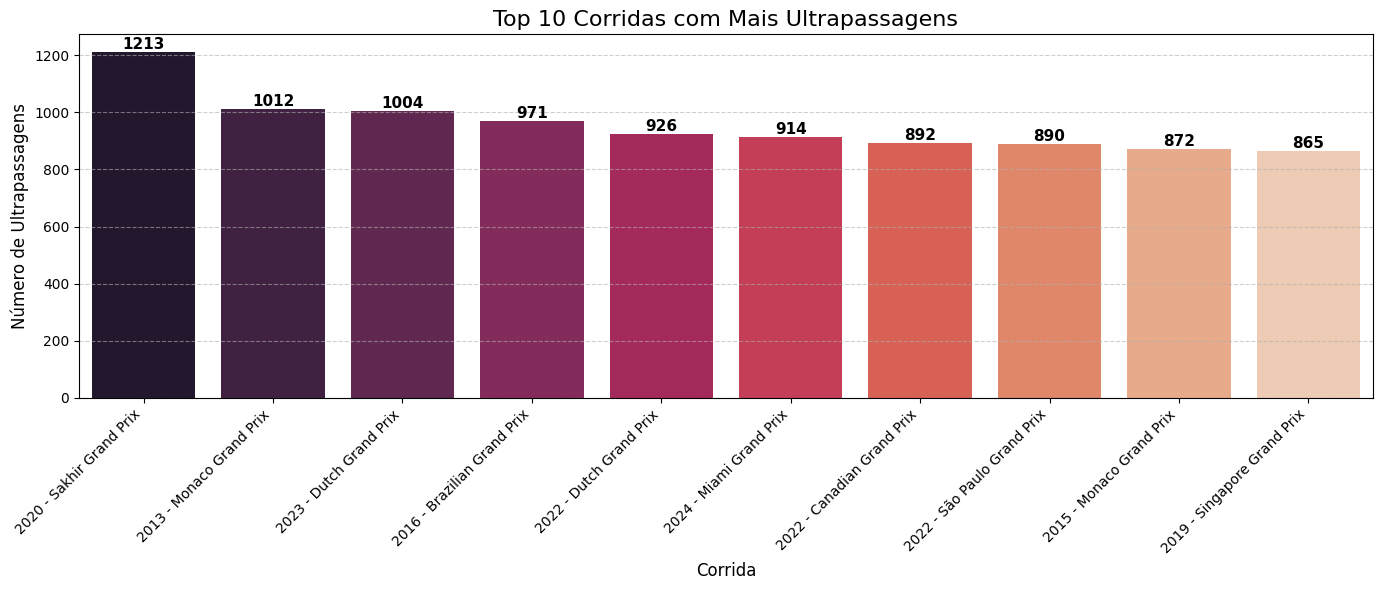

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
ultrapassagens = pd.read_csv("ultrapassagens_por_corrida.csv")
corridas = pd.read_csv("races.csv")

# Renomear colunas
ultrapassagens.columns = ["raceId", "ultrapassagens"]

# Juntar com informações da corrida (nome do GP e ano)
ultrapassagens = ultrapassagens.merge(corridas[["raceId", "name", "year"]], on="raceId", how="left")

# Criar rótulo mais amigável: "Ano - Nome do GP"
ultrapassagens["corrida"] = ultrapassagens["year"].astype(str) + " - " + ultrapassagens["name"]

# Selecionar top 10
top10 = ultrapassagens.sort_values(by="ultrapassagens", ascending=False).head(10)

# Gráfico
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="corrida", y="ultrapassagens", data=top10, palette="rocket")

# Customizações
plt.title("Top 10 Corridas com Mais Ultrapassagens", fontsize=16)
plt.xlabel("Corrida", fontsize=12)
plt.ylabel("Número de Ultrapassagens", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Labels nas barras
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()
